In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PENGUMPULAN DATA

In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/semhas kode/data radiosonde 19-25_gabung.xlsx'

df = pd.read_excel(file_path)
df

,Tanggal,850 00.00,850 12.00,700 00.00,700 12.00,500 00.00,500 12.00,SWEAT 00.00,SWEAT 12.00,LCL 00.00,...,CIN 12.00,MVV 00.00,MVV 12.00,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72,38,55.0,"227,2","227,5",403,...,-24,41,55,0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92,86,94.0,"206,1","237,3",503,...,-42,41,35,0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89,100,98.0,"221,7","223,8",194,...,-21,39,44,"6,8",12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70,94,72.0,"198,4","223,4",168,...,0,33,70,"38,5",10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65,81,80.0,"220,2","193,1",168,...,-22,42,64,1,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,NaN,NaN,NaN,NaN,NaN,NaN,205.2,0,404,...,NaN,NaN,NaN,10,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,NaN,NaN,NaN,NaN,NaN,NaN,188.5,232.9,155,...,NaN,NaN,NaN,10,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,NaN,NaN,NaN,NaN,NaN,NaN,183.6,242.5,430,...,NaN,NaN,NaN,0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,NaN,NaN,NaN,NaN,NaN,NaN,219.9,220.8,185,...,NaN,NaN,NaN,0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PREPROCESSING

In [4]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('.', '', regex=False)

In [5]:
# konversi data
df = df.replace(',', '.', regex=True)
exclude_cols = ['Tanggal']
for col in df.columns:
    if col not in exclude_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['Tanggal'] = pd.to_datetime(df['Tanggal'])

In [6]:
df

,Tanggal,850_0000,850_1200,700_0000,700_1200,500_0000,500_1200,SWEAT_0000,SWEAT_1200,LCL_0000,...,CIN_1200,MVV_0000,MVV_1200,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72.0,38.0,55.0,227.2,227.5,403.0,...,-24.0,41.0,55.0,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92.0,86.0,94.0,206.1,237.3,503.0,...,-42.0,41.0,35.0,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89.0,100.0,98.0,221.7,223.8,194.0,...,-21.0,39.0,44.0,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70.0,94.0,72.0,198.4,223.4,168.0,...,0.0,33.0,70.0,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65.0,81.0,80.0,220.2,193.1,168.0,...,-22.0,42.0,64.0,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,NaN,NaN,NaN,NaN,NaN,NaN,205.2,0.0,404.0,...,NaN,NaN,NaN,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,NaN,NaN,NaN,NaN,NaN,NaN,188.5,232.9,155.0,...,NaN,NaN,NaN,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,NaN,NaN,NaN,NaN,NaN,NaN,183.6,242.5,430.0,...,NaN,NaN,NaN,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,NaN,NaN,NaN,NaN,NaN,NaN,219.9,220.8,185.0,...,NaN,NaN,NaN,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [7]:
# Cek missing value
df.isnull().sum()

,0
Tanggal,0
850_0000,375
850_1200,912
700_0000,375
700_1200,912
500_0000,376
500_1200,912
SWEAT_0000,49
SWEAT_1200,707
LCL_0000,47


In [8]:
# missing value
df = df.interpolate(method='linear')
df

,Tanggal,850_0000,850_1200,700_0000,700_1200,500_0000,500_1200,SWEAT_0000,SWEAT_1200,LCL_0000,...,CIN_1200,MVV_0000,MVV_1200,CH,Height,Press0,Temp0,Humi0,WS,WD
0,2019-01-01,81.0,81.0,85.0,72.0,38.0,55.0,227.2,227.5,403.0,...,-24.0,41.0,55.0,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528
1,2019-01-02,81.0,93.0,83.0,92.0,86.0,94.0,206.1,237.3,503.0,...,-42.0,41.0,35.0,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639
2,2019-01-03,93.0,83.0,96.0,89.0,100.0,98.0,221.7,223.8,194.0,...,-21.0,39.0,44.0,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931
3,2019-01-04,87.0,77.0,83.0,70.0,94.0,72.0,198.4,223.4,168.0,...,0.0,33.0,70.0,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133
4,2019-01-05,85.0,71.0,65.0,65.0,81.0,80.0,220.2,193.1,168.0,...,-22.0,42.0,64.0,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,85.0,87.0,72.0,80.0,81.0,89.0,205.2,0.0,404.0,...,-16.0,14.0,57.5,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707
2553,2025-12-27,85.0,87.0,72.0,80.0,81.0,89.0,188.5,232.9,155.0,...,-16.0,14.0,57.5,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344
2554,2025-12-28,85.0,87.0,72.0,80.0,81.0,89.0,183.6,242.5,430.0,...,-16.0,14.0,57.5,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793
2555,2025-12-29,85.0,87.0,72.0,80.0,81.0,89.0,219.9,220.8,185.0,...,-16.0,14.0,57.5,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511


In [9]:
df.isnull().sum()

,0
Tanggal,0
850_0000,0
850_1200,0
700_0000,0
700_1200,0
500_0000,0
500_1200,0
SWEAT_0000,0
SWEAT_1200,0
LCL_0000,0


In [10]:
# rata-rata
df['850_avg'] = (df['850_0000'] + df['850_1200']) / 2
df['700_avg'] = (df['700_0000'] + df['700_1200']) / 2
df['500_avg'] = (df['500_0000'] + df['500_1200']) / 2

df['SWEAT_avg'] = (df['SWEAT_0000'] + df['SWEAT_1200']) / 2

df['LCL_avg'] = (df['LCL_0000'] + df['LCL_1200']) / 2
df['CCL_avg'] = (df['CCL_0000'] + df['CCL_1200']) / 2
df['LFC_avg'] = (df['LFC_0000'] + df['LFC_1200']) / 2

df['LI_avg'] = (df['LI_0000'] + df['LI_1200']) / 2
df['KI_avg'] = (df['KI_0000'] + df['KI_1200']) / 2

df['CAPE_avg'] = (df['CAPE_0000'] + df['CAPE_1200']) / 2

df['SI_avg'] = (df['SI_0000'] + df['SI_1200']) / 2

df['TT_avg'] = (df['TT_0000'] + df['TT_1200']) / 2

df['KO_avg'] = (df['KO_0000'] + df['KO_1200']) / 2

df['TPW_avg'] = (df['TPW_0000'] + df['TPW_1200']) / 2

df['BOYDEN_avg'] = (df['BOYDEN_0000'] + df['BOYDEN_1200']) / 2

df['CIN_avg'] = (df['CIN_0000'] + df['CIN_1200']) / 2

df['MVV_avg'] = (df['MVV_0000'] + df['MVV_1200']) / 2

In [11]:
df = df[
    ['Tanggal', 'CH', 'Height', 'Press0', 'Temp0', 'Humi0', 'WS', 'WD']
    + [col for col in df.columns if col.endswith('_avg')]
]

# Hapus suffix "_avg"
df.rename(columns=lambda x: x.replace('_avg', ''), inplace=True)

df

/tmp/ipykernel_2016/3907718637.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns=lambda x: x.replace('_avg', ''), inplace=True)


,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
0,2019-01-01,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528,81.0,78.5,...,-2.50,18.25,1183.0,0.00,43.10,-5.00,5745.0,96.45,-50.5,48.00
1,2019-01-02,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639,87.0,87.5,...,-2.50,36.55,731.0,0.00,43.50,-3.60,6095.0,96.15,-42.5,38.00
2,2019-01-03,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931,88.0,92.5,...,-2.50,18.50,858.5,0.00,42.70,-1.35,6185.0,96.35,-37.0,41.50
3,2019-01-04,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133,82.0,76.5,...,-3.75,33.20,1513.5,0.00,42.25,-6.95,5575.0,95.80,-23.5,51.50
4,2019-01-05,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407,78.0,65.0,...,-4.95,31.95,1462.0,0.00,43.50,-9.50,5485.0,95.90,-21.5,53.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707,86.0,76.0,...,-1.50,17.05,544.5,0.00,22.10,-4.45,6371.5,95.65,-107.5,35.75
2553,2025-12-27,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344,86.0,76.0,...,-2.50,32.75,664.5,-0.45,44.30,-11.05,6371.5,95.65,-107.5,35.75
2554,2025-12-28,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793,86.0,76.0,...,-3.50,35.25,1915.0,0.25,43.00,-11.05,6371.5,95.65,-107.5,35.75
2555,2025-12-29,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511,86.0,76.0,...,-3.00,30.55,1527.5,-0.55,43.25,-13.65,6371.5,95.65,-107.5,35.75


In [12]:
import pandas as pd

file_path = '/content/drive/MyDrive/semhas kode/dataset_bersih.xlsx'

df = pd.read_excel(file_path)
df

,Tanggal,CH,Height,Press0,Temp0,Humi0,WS,WD,850,700,...,LI,KI,CAPE,SI,TT,KO,TPW,BOYDEN,CIN,MVV
0,2019-01-01,0.0,11244.485765,338.183767,-35.773167,55.322895,10.856032,168.551528,81.0,78.5,...,-2.50,18.25,1183.0,0.00,43.10,-5.00,5745.0,96.45,-50.5,48.00
1,2019-01-02,0.0,11297.744256,342.363058,-32.865369,59.159663,9.107495,136.160639,87.0,87.5,...,-2.50,36.55,731.0,0.00,43.50,-3.60,6095.0,96.15,-42.5,38.00
2,2019-01-03,6.8,12206.825097,310.191993,-39.077880,62.002273,10.937249,157.966931,88.0,92.5,...,-2.50,18.50,858.5,0.00,42.70,-1.35,6185.0,96.35,-37.0,41.50
3,2019-01-04,38.5,10883.828545,358.674046,-32.074478,60.591993,10.877018,202.220133,82.0,76.5,...,-3.75,33.20,1513.5,0.00,42.25,-6.95,5575.0,95.80,-23.5,51.50
4,2019-01-05,1.0,8312.081650,478.850790,-17.090369,56.927706,8.760821,248.055407,78.0,65.0,...,-4.95,31.95,1462.0,0.00,43.50,-9.50,5485.0,95.90,-21.5,53.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,2025-12-26,10.0,14481.718041,263.328067,-40.439256,26.346737,10.972894,116.846707,86.0,76.0,...,-1.50,17.05,544.5,0.00,22.10,-4.45,6371.5,95.65,-107.5,35.75
2553,2025-12-27,10.0,13922.148288,274.356514,-39.774634,24.766886,11.362708,120.151344,86.0,76.0,...,-2.50,32.75,664.5,-0.45,44.30,-11.05,6371.5,95.65,-107.5,35.75
2554,2025-12-28,0.0,14667.578171,262.856572,-39.740295,21.007110,11.518194,119.120793,86.0,76.0,...,-3.50,35.25,1915.0,0.25,43.00,-11.05,6371.5,95.65,-107.5,35.75
2555,2025-12-29,0.0,13627.366019,278.848591,-39.567432,22.379381,11.409273,111.423511,86.0,76.0,...,-3.00,30.55,1527.5,-0.55,43.25,-13.65,6371.5,95.65,-107.5,35.75


EDA

In [ ]:
# statistik deskriptif
df.describe()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Jumlah subplot
n = len(df)
n_cols = 4
n_rows = int(np.ceil(n / n_cols))

# Buat figure
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3 * n_rows),
    sharex=True
)

# Ubah axes menjadi 1 dimensi
axes = np.array(axes).flatten()

# Plot masing-masing variabel
for i, kolom in enumerate(variabel):
    axes[i].plot(
        df["Tanggal"],
        df[kolom],
        linewidth=0.7
    )

    axes[i].set_title(kolom, fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis="x", rotation=30)

# Hapus subplot kosong
for i in range(len(variabel), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(
    "Visualisasi Variabel Meteorologi",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
df_daily = (
    df.set_index('Tanggal')['CH']
    .resample('D')
    .first()
)

plt.figure(figsize=(15,5))

plt.plot(
    df_daily.index,
    df_daily.values
)
plt.title('Distribusi Curah Hujan')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan (mm)')
plt.grid(True)

plt.show()

In [14]:
pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00


In [15]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 15.7 MB/s eta 0:00:00


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from pytorch_tabnet.tab_model import TabNetRegressor

from statsmodels.tsa.stattools import ccf

from xgboost import XGBRegressor

import optuna

In [17]:
# Pastikan tanggal bertipe datetime
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

# Urutkan berdasarkan waktu
df = df.sort_values(
    "Tanggal"
).reset_index(drop=True)

MENENTUKAN TARGET DAN FITUR AWAL

In [18]:
target = "CH"

features_awal = [
    col for col in df.columns
    if col not in ["Tanggal", target]
]

print("\nJumlah fitur awal :", len(features_awal))
print(features_awal)



Jumlah fitur awal : 23
['Height', 'Press0', 'Temp0', 'Humi0', 'WS', 'WD', '850', '700', '500', 'SWEAT', 'LCL', 'CCL', 'LFC', 'LI', 'KI', 'CAPE', 'SI', 'TT', 'KO', 'TPW', 'BOYDEN', 'CIN', 'MVV']


CHRONOLOGICAL TRAIN-TEST SPLIT

In [19]:
train_mask = df["Tanggal"].dt.year <= 2024
test_mask = df["Tanggal"].dt.year == 2025

df_train = df.loc[
    train_mask
].copy()

df_test = df.loc[
    test_mask
].copy()

In [20]:
print("\nTRAINING")
print("Periode :",
      df_train["Tanggal"].min(),
      "sampai",
      df_train["Tanggal"].max())

print("Jumlah :", len(df_train))

print("\nTESTING")
print("Periode :",
      df_test["Tanggal"].min(),
      "sampai",
      df_test["Tanggal"].max())

print("Jumlah :", len(df_test))


TRAINING
Periode : 2019-01-01 00:00:00 sampai 2024-12-31 00:00:00
Jumlah : 2194

TESTING
Periode : 2025-01-01 00:00:00 sampai 2025-12-30 00:00:00
Jumlah : 363


PEARSON CORRELATION SCREENING

In [21]:
pearson_result = []

for feature in features_awal:

    r = df_train[feature].corr(
        df_train[target],
        method="pearson"
    )

    pearson_result.append({
        "Feature": feature,
        "Pearson_r": r,
        "Abs_r": abs(r)
    })


pearson_df = pd.DataFrame(
    pearson_result
)

pearson_df = pearson_df.sort_values(
    "Abs_r",
    ascending=False
).reset_index(drop=True)


# Threshold Pearson
pearson_threshold = 0.07

features_pearson = pearson_df.loc[
    pearson_df["Abs_r"] >= pearson_threshold,
    "Feature"
].tolist()

In [22]:
print(
    "\nJumlah fitur awal :",
    len(features_awal)
)

print(
    "Threshold |r| >= ",
    pearson_threshold
)

print(
    "Jumlah fitur setelah Pearson :",
    len(features_pearson)
)

display(pearson_df)



Jumlah fitur awal : 23
Threshold |r| >=  0.07
Jumlah fitur setelah Pearson : 19


,Feature,Pearson_r,Abs_r
0,Humi0,0.365735,0.365735
1,LCL,-0.322427,0.322427
2,700,0.296928,0.296928
3,500,0.291545,0.291545
4,TPW,0.291313,0.291313
5,850,0.248496,0.248496
6,KI,0.243452,0.243452
7,CCL,-0.209876,0.209876
8,TT,0.195633,0.195633
9,SI,-0.174330,0.174330


DATA TABNET

In [23]:
X_train_tabnet = df_train[
    features_pearson
].copy()

y_train_tabnet = df_train[
    target
].copy()

In [24]:
scaler_tabnet = StandardScaler()

X_scaled = scaler_tabnet.fit_transform(
    X_train_tabnet
)


TABNET FEATURE SELECTION

In [25]:
# 90% untuk training, 10% untuk validation
split_val = int(len(X_train_tabnet) * 0.9)

X_tr = X_train_tabnet.iloc[:split_val]
X_val = X_train_tabnet.iloc[split_val:]

y_tr = y_train_tabnet.iloc[:split_val]
y_val = y_train_tabnet.iloc[split_val:]

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

In [27]:
for fitur in ["Humi0", "LCL", "700"]:
    i = X_tr.columns.get_loc(fitur)

    print(f"\n{fitur}")
    print("Mean :", scaler.mean_[i])
    print("Std  :", scaler.scale_[i])


Humi0
Mean : 37.84467118420656
Std  : 14.466446164012462

LCL
Mean : 408.65944782168185
Std  : 197.50904751740282

700
Mean : 63.650405268490374
Std  : 21.42812282493746


In [28]:
tabnet = TabNetRegressor(
    n_d=32,
    n_a=32,
    n_steps=7,
    gamma=1.8,
    lambda_sparse=1e-7,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.005),
    seed=42,
    verbose=1
)

tabnet.fit(
    X_train=X_tr_scaled,
    y_train=y_tr.values.reshape(-1, 1),

    eval_set=[
        (X_tr_scaled, y_tr.values.reshape(-1, 1)),
        (X_val_scaled, y_val.values.reshape(-1, 1))
    ],

    eval_name=["train", "valid"],
    eval_metric=["rmse"],

    max_epochs=100,
    patience=50,
    batch_size=64,
    virtual_batch_size=32
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 264.35819| train_rmse: 15.56551| valid_rmse: 12.36803|  0:00:07s
epoch 1  | loss: 239.96182| train_rmse: 15.50261| valid_rmse: 12.14859|  0:00:12s
epoch 2  | loss: 230.78663| train_rmse: 15.32818| valid_rmse: 11.60606|  0:00:18s
epoch 3  | loss: 232.21339| train_rmse: 15.13184| valid_rmse: 11.86435|  0:00:23s
epoch 4  | loss: 232.10069| train_rmse: 15.12877| valid_rmse: 13.05742|  0:00:24s
epoch 5  | loss: 230.20056| train_rmse: 15.12827| valid_rmse: 13.02551|  0:00:26s
epoch 6  | loss: 242.7335| train_rmse: 15.25265| valid_rmse: 13.3882 |  0:00:28s
epoch 7  | loss: 221.15496| train_rmse: 14.89758| valid_rmse: 13.05044|  0:00:30s
epoch 8  | loss: 222.36654| train_rmse: 14.86802| valid_rmse: 11.7234 |  0:00:33s
epoch 9  | loss: 222.41782| train_rmse: 14.86209| valid_rmse: 11.33043|  0:00:36s
epoch 10 | loss: 224.70002| train_rmse: 15.33323| valid_rmse: 12.46746|  0:00:38s
epoch 11 | loss: 230.12258| train_rmse: 14.94366| valid_rmse: 11.32205|  0:00:40s
epoch 12 | loss: 

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


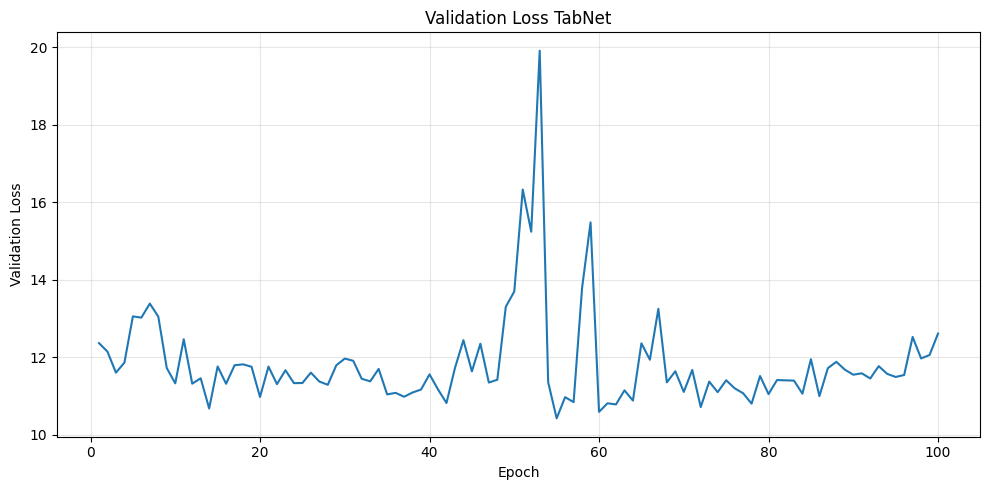

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(tabnet.history["valid_rmse"]) + 1),
    tabnet.history["valid_rmse"],
    linewidth=1.5
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss TabNet")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# 5 data yang digunakan
X_manual = X_scaled[:5]
y_manual = y_train_tabnet.iloc[:5].values

# Prediksi TabNet
pred_manual = tabnet.predict(X_manual).flatten()

print("X setelah standardisasi:")
print(X_manual)

print("\nY aktual:")
print(y_manual)

print("\nY prediksi:")
print(pred_manual)

print("\nFeature importance:")
print(tabnet.feature_importances_)

X setelah standardisasi:
[[ 1.24575204  0.59143222  0.72919257 -0.29880905  0.45325483  0.32397341
  -0.95295851  0.29019817  0.42147433 -0.46510013 -0.00757306 -0.89761364
   0.33238878  0.35955501  0.46685601 -0.04758822 -0.3517634   1.45320016
   0.08870238]
 [ 1.50950243 -0.57546828  1.13980379  1.30254519  0.76162138  0.82824914
   0.77870213 -0.18021843  0.51977774 -0.46510013 -0.00757306 -0.86827726
   0.25031162  0.48384533  0.53246706 -0.54648951 -0.52781828  1.77538763
   0.50226823]
 [ 1.70491155 -1.17551558  1.36792113  1.63385986  0.84091564  0.9122951
  -0.92930194 -0.37315427  0.32317093 -0.46510013 -0.00757306 -0.36752825
   0.2655649   0.56929492  0.02741067 -0.40575961 -0.99562122  2.29318891
  -0.38131528]
 [ 1.60796488 -0.30480864  0.63794564  1.044856    0.3034768   0.40801937
   0.46170414 -0.27560244  0.2125796  -0.46510013 -0.60140089 -1.09627446
   0.09342078  0.77903484  0.7885347   0.31720575 -0.86169376  1.00443904
   0.61475379]
 [ 1.35607135  0.57611186  0

In [31]:
masks = tabnet.explain(X_manual)

print("Feature mask:")
print(masks[0])

Feature mask:
[[16.60564232  0.          0.          0.          3.56043506  0.
  24.78367424  0.          0.          3.79411888  0.          3.34921288
   1.24687457  0.          4.16295242  1.44945645  0.70595402  1.19967318
   0.49814692]
 [ 0.          4.65341568  7.16302633  6.00792503  0.          1.50795364
   5.93752956  0.          0.          0.          0.          7.96502066
   0.          0.          0.          0.          7.93115425  0.
   0.        ]
 [ 1.4776516   0.          0.          0.          4.79329395  0.1086368
   1.24676657  0.          0.          0.53015697  1.46844649  2.78471899
   0.          0.          1.73647237  1.593925   28.89113617 23.63717461
   1.16529536]
 [21.39697647  0.          0.          0.          1.8879596   2.50204372
   0.95566255  0.          0.1541969   2.13108706  0.          0.
   0.          0.          5.69569111  2.48606563  0.20932576  0.38075784
   1.63743186]
 [18.06554222  0.          0.81292021  0.          1.41328967  

FEATURE IMPORTANCE TABNET

In [32]:
importance = tabnet.feature_importances_


feature_importance = pd.DataFrame({
    "Feature": features_pearson,
    "Importance": importance
})


feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


In [33]:
N_FEATURES = 15

selected_features = feature_importance.head(
    N_FEATURES
)["Feature"].tolist()
display(
    feature_importance.head(15)
)

,Feature,Importance
0,Humi0,0.102362
1,700,0.095957
2,LFC,0.092347
3,CAPE,0.072812
4,Height,0.072004
5,TPW,0.066853
6,KI,0.061317
7,SI,0.058634
8,500,0.054723
9,TT,0.054402


PENENTUAN LAG DENGAN CCF
CCF digunakan untuk melihat hubungan antara:
X(t-lag) -> CH(t)
CCF dilakukan hanya pada DATA TRAINING.
MAX_LAG = 7 hari
Lag setiap fitur dapat berbeda.

In [34]:
MAX_LAG = 7

lag_results = []


for feature in selected_features:

    x = df_train[feature].values
    y = df_train[target].values

    # Hilangkan kemungkinan NaN
    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    # CCF
    ccf_values = ccf(
        x,
        y,
        adjusted=False
    )

    # Kandidat lag 1-7
    candidate_ccf = ccf_values[
        1:MAX_LAG + 1
    ]
     # Lag dengan absolut CCF terbesar
    best_idx = np.argmax(
        np.abs(candidate_ccf)
    )

    best_lag = best_idx + 1

    best_ccf = candidate_ccf[
        best_idx
    ]

    lag_results.append({
        "Feature": feature,
        "Lag": best_lag,
        "CCF": best_ccf,
        "Abs_CCF": abs(best_ccf)
    })


lag_df = pd.DataFrame(
    lag_results
)

lag_df = lag_df.sort_values(
    "Abs_CCF",
    ascending=False
).reset_index(drop=True)
display(lag_df)

,Feature,Lag,CCF,Abs_CCF
0,Humi0,1,0.322576,0.322576
1,TPW,1,0.264984,0.264984
2,700,1,0.262956,0.262956
3,LCL,1,-0.257148,0.257148
4,500,1,0.248329,0.248329
5,KI,1,0.220101,0.220101
6,850,4,0.210695,0.210695
7,LI,1,-0.175745,0.175745
8,SI,1,-0.166341,0.166341
9,TT,3,0.159531,0.159531


In [35]:
selected_lags = dict(
    zip(
        lag_df["Feature"],
        lag_df["Lag"]
    )
)

print("\nLag yang digunakan:")

for feature, lag in selected_lags.items():

    print(
        f"{feature} -> lag {lag}"
    )


Lag yang digunakan:
Humi0 -> lag 1
TPW -> lag 1
700 -> lag 1
LCL -> lag 1
500 -> lag 1
KI -> lag 1
850 -> lag 4
LI -> lag 1
SI -> lag 1
TT -> lag 3
CAPE -> lag 3
Height -> lag 1
LFC -> lag 1
Press0 -> lag 7
Temp0 -> lag 7


MEMBENTUK DATA LAG
membentuk lag berdasarkan fitur yang sudah dipilih oleh TabNet.
Setiap fitur menggunakan lag hasil CCF masing-masing.

In [36]:
df_model = df[
    ["Tanggal", target] + selected_features
].copy()

df_model = df_model.sort_values(
    "Tanggal"
).reset_index(drop=True)


for feature, lag in selected_lags.items():

    df_model[
        f"{feature}_lag{lag}"
    ] = df_model[
        feature
    ].shift(lag)



In [37]:
CH_LAG = 1

df_model[
    f"CH_lag{CH_LAG}"
] = df_model[
    "CH"
].shift(CH_LAG)


 FITUR MUSIMAN

In [38]:
df_model["month"] = (
    df_model["Tanggal"].dt.month
)

df_model["month_sin"] = np.sin(
    2 * np.pi *
    df_model["month"] / 12
)

df_model["month_cos"] = np.cos(
    2 * np.pi *
    df_model["month"] / 12
)


MENGHAPUS BARIS AKIBAT LAG

In [39]:
df_model = df_model.dropna(
    subset=[
        f"{feature}_lag{lag}"
        for feature, lag
        in selected_lags.items()
    ]
    +
    [f"CH_lag{CH_LAG}"]
).reset_index(drop=True)


print(df_model.shape)

(2550, 36)


In [40]:
df_model

,Tanggal,CH,Humi0,700,LFC,CAPE,Height,TPW,KI,SI,...,TT_lag3,CAPE_lag3,Height_lag1,LFC_lag1,Press0_lag7,Temp0_lag7,CH_lag1,month,month_sin,month_cos
0,2019-01-08,6.4,30.210083,65.5,1304.5,1653.5,12199.843207,5400.0,34.30,0.00,...,43.50,1462.0,8715.312832,1867.5,338.183767,-35.773167,0.0,1,5.000000e-01,0.866025
1,2019-01-09,0.0,32.686168,51.5,1119.0,2436.5,13079.497675,5055.0,27.90,0.00,...,43.10,1641.5,12199.843207,1304.5,342.363058,-32.865369,6.4,1,5.000000e-01,0.866025
2,2019-01-10,0.0,54.263664,52.0,1087.5,1949.0,11633.080787,5685.0,32.40,0.00,...,44.35,1109.0,13079.497675,1119.0,310.191993,-39.077880,0.0,1,5.000000e-01,0.866025
3,2019-01-11,0.5,41.852026,70.5,2466.0,576.0,11884.069487,5485.0,34.45,0.00,...,46.20,1653.5,11633.080787,1087.5,358.674046,-32.074478,0.0,1,5.000000e-01,0.866025
4,2019-01-12,2.0,42.715199,48.5,1687.5,1014.0,12734.208882,5360.0,27.60,0.00,...,42.80,2436.5,11884.069487,2466.0,478.850790,-17.090369,0.5,1,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2545,2025-12-26,10.0,26.346737,76.0,881.5,544.5,14481.718041,6371.5,17.05,0.00,...,43.15,1551.5,14796.762533,1186.0,267.332154,-39.322015,35.0,12,-2.449294e-16,1.000000
2546,2025-12-27,10.0,24.766886,76.0,2828.5,664.5,13922.148288,6371.5,32.75,-0.45,...,45.05,1431.0,14481.718041,881.5,288.810663,-38.897269,10.0,12,-2.449294e-16,1.000000
2547,2025-12-28,0.0,21.007110,76.0,1442.0,1915.0,14667.578171,6371.5,35.25,0.25,...,44.35,1867.0,13922.148288,2828.5,265.720775,-39.426488,10.0,12,-2.449294e-16,1.000000
2548,2025-12-29,0.0,22.379381,76.0,1574.5,1527.5,13627.366019,6371.5,30.55,-0.55,...,22.10,544.5,14667.578171,1442.0,279.191697,-38.785340,0.0,12,-2.449294e-16,1.000000


MENENTUKAN FITUR SVR

In [41]:
lag_features = [
    f"{feature}_lag{lag}"
    for feature, lag
    in selected_lags.items()
]


svr_features = (
    lag_features
    +
    [f"CH_lag{CH_LAG}"]
    +
    [
        "month",
        "month_sin",
        "month_cos"
    ]
)


print("\nJumlah fitur SVR:",
      len(svr_features))


print("\nFitur SVR:")
print(svr_features)


Jumlah fitur SVR: 19

Fitur SVR:
['Humi0_lag1', 'TPW_lag1', '700_lag1', 'LCL_lag1', '500_lag1', 'KI_lag1', '850_lag4', 'LI_lag1', 'SI_lag1', 'TT_lag3', 'CAPE_lag3', 'Height_lag1', 'LFC_lag1', 'Press0_lag7', 'Temp0_lag7', 'CH_lag1', 'month', 'month_sin', 'month_cos']


MEMISAHKAN TRAINING DAN TESTING

In [42]:

train_model = df_model[
    df_model["Tanggal"].dt.year <= 2024
].copy()

test_model = df_model[
    df_model["Tanggal"].dt.year == 2025
].copy()

print(
    "Training :",
    train_model["Tanggal"].min(),
    "sampai",
    train_model["Tanggal"].max(),
    "| n =",
    len(train_model)
)

print(
    "Testing  :",
    test_model["Tanggal"].min(),
    "sampai",
    test_model["Tanggal"].max(),
    "| n =",
    len(test_model)
)

Training : 2019-01-08 00:00:00 sampai 2024-12-31 00:00:00 | n = 2187
Testing  : 2025-01-01 00:00:00 sampai 2025-12-30 00:00:00 | n = 363


TIME-SERIES VALIDATION UNTUK OPTUNA

In [43]:
optuna_train = train_model[
    train_model["Tanggal"].dt.year <= 2023
].copy()


optuna_valid = train_model[
    train_model["Tanggal"].dt.year == 2024
].copy()


print(
    "Optuna Training :",
    optuna_train["Tanggal"].min(),
    "sampai",
    optuna_train["Tanggal"].max(),
    "| n =",
    len(optuna_train)
)


print(
    "Validation      :",
    optuna_valid["Tanggal"].min(),
    "sampai",
    optuna_valid["Tanggal"].max(),
    "| n =",
    len(optuna_valid)
)

Optuna Training : 2019-01-08 00:00:00 sampai 2023-12-31 00:00:00 | n = 1820
Validation      : 2024-01-01 00:00:00 sampai 2024-12-31 00:00:00 | n = 367


In [44]:
X_optuna_train = optuna_train[
    svr_features
]

y_optuna_train = optuna_train[
    target
]


X_optuna_valid = optuna_valid[
    svr_features
]

y_optuna_valid = optuna_valid[
    target
]

OPTUNA

In [45]:
from sklearn.preprocessing import StandardScaler

scaler_optuna = StandardScaler()


X_optuna_train_scaled = scaler_optuna.fit_transform(
    X_optuna_train
)


X_optuna_valid_scaled = scaler_optuna.transform(
    X_optuna_valid
)

In [46]:
def objective_svr(trial):

    params = {

        "C": trial.suggest_float(
            "C",
            1e-2,
            1e3,
            log=True
        ),

        "gamma": trial.suggest_float(
            "gamma",
            1e-4,
            1e1,
            log=True
        ),

        "epsilon": trial.suggest_float(
            "epsilon",
            0.01,
            1.0
        )
    }


    model = SVR(
        kernel="rbf",
        **params
    )


    model.fit(
        X_optuna_train_scaled,
        y_optuna_train
    )


    pred_valid = model.predict(
        X_optuna_valid_scaled
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_optuna_valid,
            pred_valid
        )
    )


    return rmse

In [47]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np
import optuna

In [48]:
study_svr = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=42
    )
)


study_svr.optimize(
    objective_svr,
    n_trials=50
)

[I 2026-08-13 15:19:03,142] A new study created in memory with name: no-name-7f489b35-69a9-4d1e-a828-9b1ec0dfe5de
[I 2026-08-13 15:19:03,809] Trial 0 finished with value: 15.991912264401211 and parameters: {'C': 0.7459343285726545, 'gamma': 5.669849511478847, 'epsilon': 0.7346740023932911}. Best is trial 0 with value: 15.991912264401211.
[I 2026-08-13 15:19:04,130] Trial 1 finished with value: 15.447091553213191 and parameters: {'C': 9.846738873614559, 'gamma': 0.0006026889128682511, 'epsilon': 0.16443457513284063}. Best is trial 1 with value: 15.447091553213191.
[I 2026-08-13 15:19:04,675] Trial 2 finished with value: 16.157467639819806 and parameters: {'C': 0.0195172246414495, 'gamma': 2.1423021757741068, 'epsilon': 0.6051038616257767}. Best is trial 1 with value: 15.447091553213191.
[I 2026-08-13 15:19:04,901] Trial 3 finished with value: 15.152495119265552 and parameters: {'C': 34.70266988650411, 'gamma': 0.00012674255898937226, 'epsilon': 0.9702107536403743}. Best is trial 3 with 

In [49]:
print(
    "Best RMSE SVR :",
    study_svr.best_value
)


print(
    "\nBest Parameters SVR:"
)

print(
    study_svr.best_params
)

Best RMSE SVR : 14.033515446288698

Best Parameters SVR:
{'C': 85.18710399776029, 'gamma': 0.013663486378361508, 'epsilon': 0.4065274705384659}


TRAINING SVR

In [50]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

X_train_final = train_model[svr_features].copy()
y_train_final = train_model[target].copy()

X_test_final = test_model[svr_features].copy()
y_test_final = test_model[target].copy()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

svr = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

svr.fit(
    X_train_scaled,
    y_train_final
)


SVR(C=100)

In [51]:
pred_svr = svr.predict(
    X_test_scaled
)

EVALUASI MODEL

In [52]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_final,
        pred_svr
    )
)

mae = mean_absolute_error(
    y_test_final,
    pred_svr
)
mask = y_test_final != 0

mape = np.mean(
    np.abs(
        (
            y_test_final[mask]
            -
            pred_svr[mask]
        )
        /
        y_test_final[mask]
    )
) * 10
print(
    "RMSE :",
    round(rmse, 4)
)

print(
    "MAE  :",
    round(mae, 4)
)

print(
    "MAPE :",
    round(mape, 4),
    "%"
)

RMSE : 20.795
MAE  : 10.5287
MAPE : 13.5263 %


TABEL PREDIKSI

In [53]:
hasil_prediksi = pd.DataFrame({

    "Tanggal":
        test_model["Tanggal"].values,

    "Aktual":
        y_test_final.values,

    "Prediksi":
        pred_svr

})


print("HASIL PREDIKSI 2025")

display(
    hasil_prediksi
)


HASIL PREDIKSI 2025


,Tanggal,Aktual,Prediksi
0,2025-01-01,27.0,15.278575
1,2025-01-02,30.0,20.180180
2,2025-01-03,2.0,2.337988
3,2025-01-04,0.0,3.006850
4,2025-01-05,28.0,7.557805
...,...,...,...
358,2025-12-26,10.0,4.355617
359,2025-12-27,10.0,1.504815
360,2025-12-28,0.0,0.516172
361,2025-12-29,0.0,6.817678


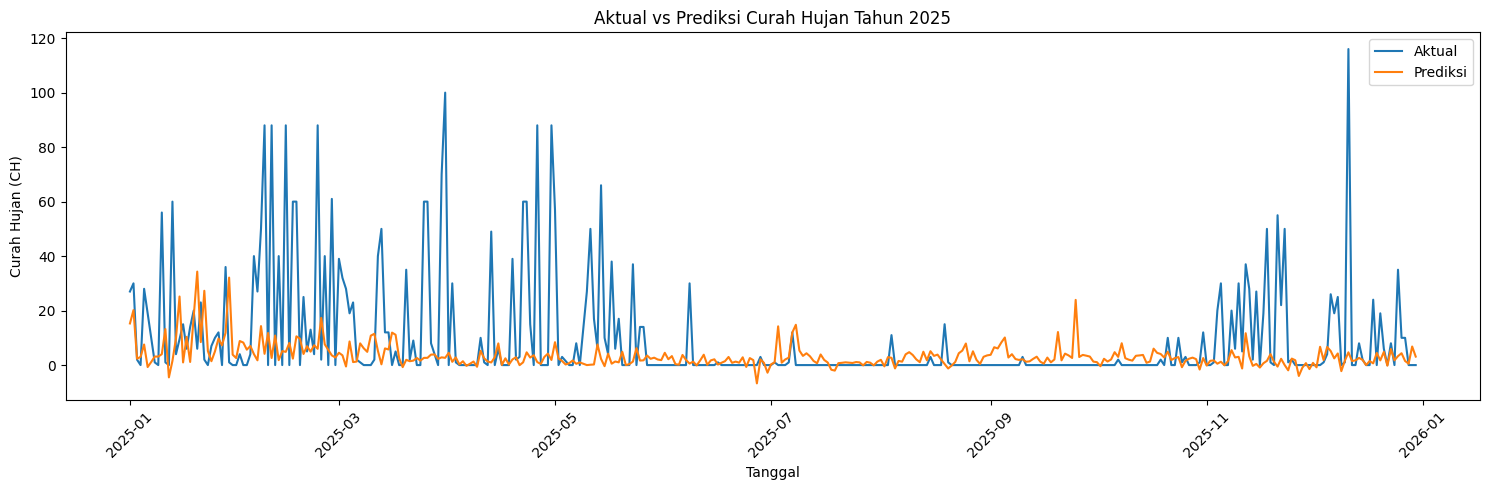

In [54]:
plt.figure(
    figsize=(15, 5)
)

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Aktual"],
    label="Aktual"
)

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Prediksi"],
    label="Prediksi"
)

plt.xlabel("Tanggal")
plt.ylabel("Curah Hujan (CH)")

plt.title(
    "Aktual vs Prediksi Curah Hujan Tahun 2025"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [55]:
# Cek variabel yang kemungkinan merupakan model
[name for name in globals()
 if "model" in name.lower() or "svr" in name.lower()]

['df_model',
 'svr_features',
 'train_model',
 'test_model',
 'objective_svr',
 'SVR',
 'study_svr',
 'svr',
 'pred_svr']

In [56]:
# Ambil data tahun 2025
data_2025 = df_model[
    df_model["Tanggal"].dt.year == 2025
].copy()

# Salin data 2025 sebagai simulasi 2026
data_2026 = data_2025.copy()

# Geser tanggal 2025 menjadi 2026
data_2026["Tanggal"] = (
    data_2026["Tanggal"] + pd.DateOffset(years=1)
)

# Ambil fitur SVR
X_2026 = data_2026[svr_features].copy()

# Standardisasi menggunakan scaler dari data training
X_2026_scaled = scaler.transform(X_2026)

# Prediksi menggunakan SVR
pred_2026 = svr.predict(X_2026_scaled)

hasil_prediksi_2026 = pd.DataFrame({
    "Tanggal": data_2026["Tanggal"].values,
    "Prediksi": pred_2026
})

print("HASIL PREDIKSI SVR 2026")

hasil_prediksi_2026

HASIL PREDIKSI SVR 2026


,Tanggal,Prediksi
0,2026-01-01,15.278575
1,2026-01-02,20.180180
2,2026-01-03,2.337988
3,2026-01-04,3.006850
4,2026-01-05,7.557805
...,...,...
358,2026-12-26,4.355617
359,2026-12-27,1.504815
360,2026-12-28,0.516172
361,2026-12-29,6.817678


In [63]:
# ============================================================
# EXPORT ULANG SVR — SESUAI OUTPUT COLAB ANDA
# ============================================================

import joblib
from google.colab import files

EXPECTED_SVR_FEATURES = [
    "Humi0_lag1",
    "TPW_lag1",
    "700_lag1",
    "LCL_lag1",
    "500_lag1",
    "KI_lag1",
    "850_lag4",
    "LI_lag1",
    "SI_lag1",
    "TT_lag3",
    "CAPE_lag3",
    "Height_lag1",
    "LFC_lag1",
    "Press0_lag7",
    "Temp0_lag7",
    "CH_lag1",
    "month",
    "month_sin",
    "month_cos",
]

print("svr_features dari Colab:")
print(svr_features)

assert list(svr_features) == EXPECTED_SVR_FEATURES, (
    "svr_features tidak sesuai dengan daftar fitur Colab."
)

print("\nFitur yang tersimpan pada scaler:")
print(list(scaler.feature_names_in_))

assert list(scaler.feature_names_in_) == EXPECTED_SVR_FEATURES, (
    "scaler_svr tidak sesuai. "
    "Buat ulang scaler dari X_train_final = train_model[svr_features]."
)

joblib.dump(svr, "hybrid_svr.pkl")
joblib.dump(scaler, "scaler_svr.pkl")

print("\nBerhasil disimpan:")
print("hybrid_svr.pkl")
print("scaler_svr.pkl")

files.download("hybrid_svr.pkl")
files.download("scaler_svr.pkl")


svr_features dari Colab:
['Humi0_lag1', 'TPW_lag1', '700_lag1', 'LCL_lag1', '500_lag1', 'KI_lag1', '850_lag4', 'LI_lag1', 'SI_lag1', 'TT_lag3', 'CAPE_lag3', 'Height_lag1', 'LFC_lag1', 'Press0_lag7', 'Temp0_lag7', 'CH_lag1', 'month', 'month_sin', 'month_cos']

Fitur yang tersimpan pada scaler:
['Humi0_lag1', 'TPW_lag1', '700_lag1', 'LCL_lag1', '500_lag1', 'KI_lag1', '850_lag4', 'LI_lag1', 'SI_lag1', 'TT_lag3', 'CAPE_lag3', 'Height_lag1', 'LFC_lag1', 'Press0_lag7', 'Temp0_lag7', 'CH_lag1', 'month', 'month_sin', 'month_cos']

Berhasil disimpan:
hybrid_svr.pkl
scaler_svr.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>